# 04B: Inference - Loyalty-Based Customer Scoring

-  Score all 96,096 customers using the loyalty prediction models (Approach 2).
- Outputs: propensity score, predicted future order value, and expected value for ad targeting.

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

df = pd.read_csv('../processed/loyalty_modelling_dataset.csv')

loyalty_model = joblib.load('../outputs/best_loyalty_model.pkl')
value_model = joblib.load('../outputs/best_loyalty_value_model.pkl')

target_cols = ['y_loyalty', 'y_future_order_value', 'y_future_order_value_log']
drop_cols = ['customer_unique_id'] + target_cols

customer_ids = df['customer_unique_id']
X_inference = df.drop(columns=drop_cols)

print(f"Loaded {len(df)} customers, {X_inference.shape[1]} features")
print(f"Loyalty model: {type(loyalty_model).__name__}")
print(f"Value model: {type(value_model).__name__}")

Loaded 96096 customers, 34 features
Loyalty model: LGBMClassifier
Value model: RandomForestRegressor


In [2]:
# Score all customers
loyalty_scores = loyalty_model.predict_proba(X_inference)[:, 1]

predicted_value_log = value_model.predict(X_inference)
predicted_value = np.expm1(predicted_value_log)
predicted_value = np.clip(predicted_value, 0, None)

expected_value = loyalty_scores * predicted_value

output_df = pd.DataFrame({
    'customer_unique_id': customer_ids,
    'loyalty_score': loyalty_scores,
    'predicted_future_order_value': predicted_value.round(2),
    'expected_value': expected_value.round(2)
})

output_df = output_df.sort_values('expected_value', ascending=False).reset_index(drop=True)

print(f"Output shape: {output_df.shape}")
print(f"\nTop 10 highest-value customers:")
print(output_df.head(10))
print(f"\nScore distribution:")
print(output_df[['loyalty_score', 'predicted_future_order_value', 'expected_value']].describe())

Output shape: (96096, 4)

Top 10 highest-value customers:
                 customer_unique_id  loyalty_score  \
0  e4d18909afd252a0289765acc614d3e0       0.931513   
1  055ec572ac7f3c7bdd04a183830ebe59       0.349455   
2  c8592d5ae5bde92205a4eedb41d9455e       0.959295   
3  934e91b0e98dbbeb3649cb1091cca051       0.919371   
4  3c5e1130694632f44051b23fd86ad9e2       0.927020   
5  952bdd2866ddfc528203799b6b7a24e1       0.916416   
6  f8ac33ce25aad89ade14c52fac3cc452       0.687290   
7  accd68fd87adda3d6360d77daafd964d       0.892509   
8  b9badb100ff8ecc16a403111209e3a06       0.800720   
9  c27a30338b5d9d59399825f77e7dcc61       0.925791   

   predicted_future_order_value  expected_value  
0                        163.86          152.64  
1                        426.07          148.89  
2                        133.27          127.84  
3                        123.69          113.71  
4                        119.54          110.82  
5                        101.11           92.66

Saved loyalty_customer_scores.csv


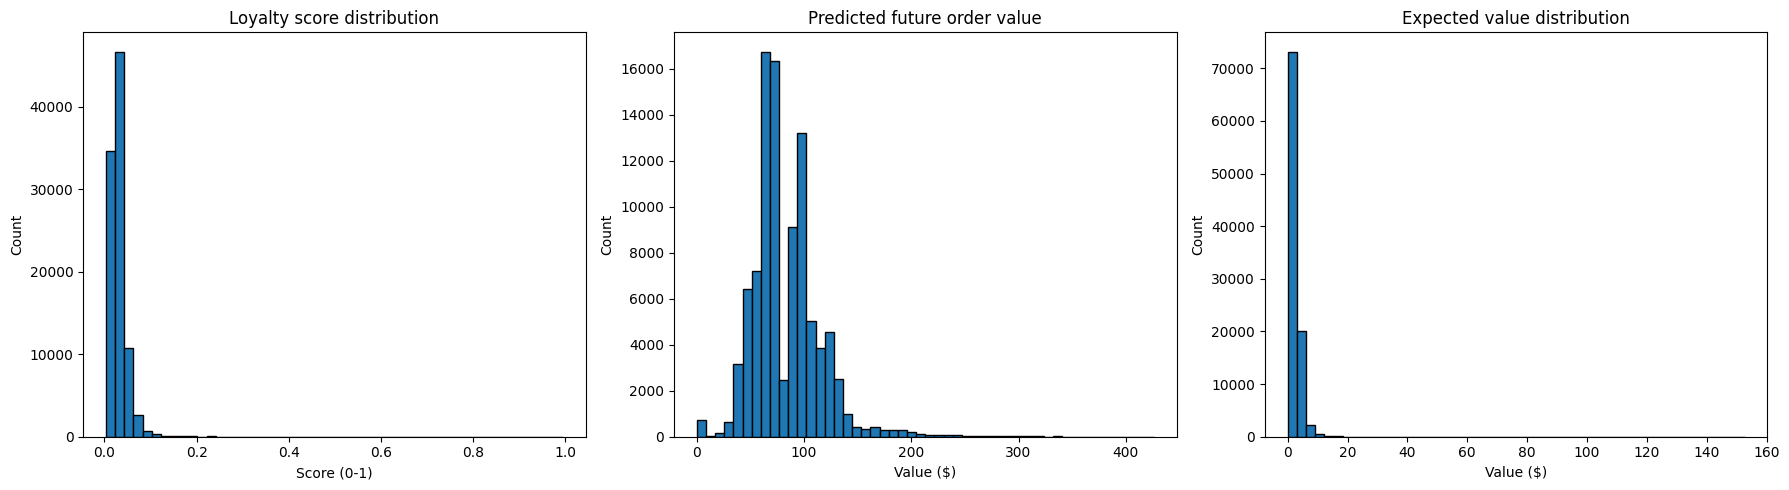

In [3]:
# Save output
output_df.to_csv('../outputs/loyalty_customer_scores.csv', index=False)
print(f"Saved loyalty_customer_scores.csv")

# Score distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(output_df['loyalty_score'], bins=50, edgecolor='black')
axes[0].set_title('Loyalty score distribution')
axes[0].set_xlabel('Score (0-1)')
axes[0].set_ylabel('Count')

axes[1].hist(output_df['predicted_future_order_value'], bins=50, edgecolor='black')
axes[1].set_title('Predicted future order value')
axes[1].set_xlabel('Value ($)')
axes[1].set_ylabel('Count')

axes[2].hist(output_df['expected_value'], bins=50, edgecolor='black')
axes[2].set_title('Expected value distribution')
axes[2].set_xlabel('Value ($)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../outputs/loyalty_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### Inference Summary - Approach 2: Loyalty Prediction

**Models used:**
- **Loyalty:** LightGBM (PR-AUC: 0.0912, ROC-AUC: 0.6412)
- **Order Value:** Random Forest Regressor (MAE: $67.13)

**Output:** `loyalty_customer_scores.csv` — 96,096 customers scored with:
- `loyalty_score` — probability of becoming a repeat buyer (0–1)
- `predicted_future_order_value` — estimated value of future orders ($)
- `expected_value` — loyalty_score × predicted_value — ranking metric for ad targeting

**Top customer:** 93.2% loyalty probability, $163.86 predicted spend → $152.64 expected value